In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [10]:
data = pd.read_csv('Train_houseprice.csv',usecols = ['BsmtQual', 'FireplaceQu','GarageType', 'SalePrice'])

In [11]:
data.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [12]:
data.shape

(1460, 4)

In [13]:
data.isnull().sum()

BsmtQual        37
FireplaceQu    690
GarageType      81
SalePrice        0
dtype: int64

In [14]:
data.columns


Index(['BsmtQual', 'FireplaceQu', 'GarageType', 'SalePrice'], dtype='object')

In [17]:
(data.isnull().sum())

BsmtQual        37
FireplaceQu    690
GarageType      81
SalePrice        0
dtype: int64

In [18]:
data.isnull().mean().sort_values(ascending = True)

SalePrice      0.000000
BsmtQual       0.025342
GarageType     0.055479
FireplaceQu    0.472603
dtype: float64


### 1.Frequent category Imputation

<AxesSubplot:xlabel='BsmtQual'>

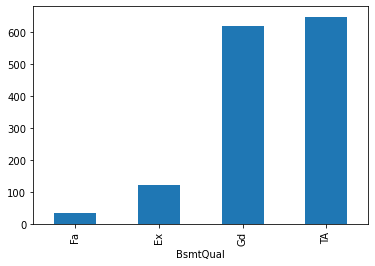

In [26]:
data.groupby(['BsmtQual'])['BsmtQual'].count().sort_values(ascending = True).plot.bar()

<AxesSubplot:>

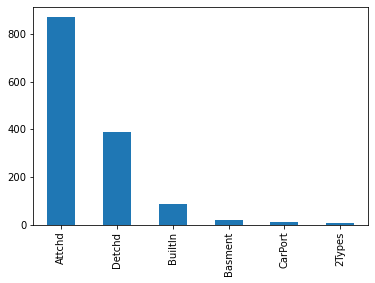

In [27]:
data['GarageType'].value_counts().plot.bar()

<AxesSubplot:>

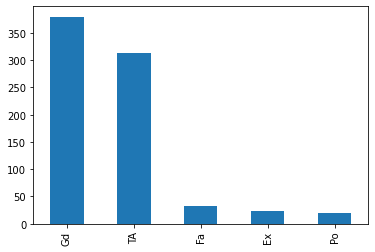

In [28]:
data['FireplaceQu'].value_counts().plot.bar()

In [32]:
def freqimp(data, variable ):
    fre = data[variable].value_counts().index[0]
    data[variable].fillna(fre, inplace = True)

In [33]:
data.columns

Index(['BsmtQual', 'FireplaceQu', 'GarageType', 'SalePrice'], dtype='object')

In [34]:
e = ['BsmtQual', 'FireplaceQu', 'GarageType', 'SalePrice']
for i in e:
    freqimp(data,i)

In [36]:
data.isnull().sum()

BsmtQual       0
FireplaceQu    0
GarageType     0
SalePrice      0
dtype: int64

In [39]:
fre = data['BsmtQual'].value_counts()

In [40]:
fre # we are just taking the first one and doing the filling options.

TA    686
Gd    618
Ex    121
Fa     35
Name: BsmtQual, dtype: int64

### 3. Adding a Variable to capture NAN.
* if we have lots of NAN values in the data we can use this tehnique.

In [46]:
data = pd.read_csv('Train_houseprice.csv',usecols = ['BsmtQual', 'FireplaceQu','GarageType', 'SalePrice'])

In [47]:
data.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [48]:
data['BsmtQual_var'] = np.where(data['BsmtQual'].isnull(), 1, 0)

In [49]:
data.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0


In [52]:
df = 

In [54]:
data['BsmtQual_var'].fillna(df,inplace = True)

In [55]:
# Here we are just capturing the null values by adding new feature.

In [56]:
data['FireplaceQu_var'] = np.where(data['FireplaceQu'].isnull(), 1, 0)
fre = data['FireplaceQu_var'].value_counts().index[0]
data['FireplaceQu_var'].fillna(fre,inplace = True)


In [57]:
data.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var,FireplaceQu_var
0,Gd,NaN,Attchd,208500,0,1
1,Gd,TA,Attchd,181500,0,0
2,Gd,TA,Attchd,223500,0,0
3,TA,Gd,Detchd,140000,0,0
4,Gd,TA,Attchd,250000,0,0


In [58]:
# we capture the importance of the null values.. 

In [59]:
# here's the subpart of this topic

* Instead of using more frequent values, we will create a new values.

In [65]:
def imp(data, variable):
    data[variable+'_new'] = np.where(data[variable].isnull(), 'Missing', data[variable])

In [66]:
e = ['BsmtQual', 'FireplaceQu', 'GarageType', 'SalePrice']
for i in e:
    imp(data,i)

In [67]:
data.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var,FireplaceQu_var,BsmtQual_new,FireplaceQu_new,GarageType_new,SalePrice_new
0,Gd,NaN,Attchd,208500,0,1,Gd,Missing,Attchd,208500
1,Gd,TA,Attchd,181500,0,0,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500,0,0,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000,0,0,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000,0,0,Gd,TA,Attchd,250000
